<a href="https://colab.research.google.com/github/kate5926/diabetes/blob/main/DIABETES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**DIABETES**

> Agregar bloque entrecomillado



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency


**Etapa 1: Formulacion de pregunta**



*   ¿Qué factores pueden influyeir en la deteccion de diabetes?
*   ¿Qué combinación de indicadores físicos (presión, peso) y hábitos de vida (ejercicio, dieta) permite predecir si una persona tiene diabetes?



**Etapa 2: Adquisición de datos y limpieza**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
ruta = '/content/drive/MyDrive/Colab Notebooks/diabetes_binary_health_indicators_BRFSS2015.csv'

In [ ]:
data = pd.read_csv(ruta)
print(f"Dimensiones del dataset: {data.shape}")


Dimensiones del dataset: (253680, 22)


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [ ]:
# Diccionario de traducción
diccionario_nombres = {
    'Diabetes_binary': 'Diabetes',
    'HighBP': 'Presion_Alta',
    'HighChol': 'Colesterol_Alto',
    'CholCheck': 'Chequeo_Colesterol',
    'BMI': 'IMC',
    'Smoker': 'Fumador',
    'Stroke': 'Derrame_Cerebral',
    'HeartDiseaseorAttack': 'Enfermedad_Cardiaca',
    'PhysActivity': 'Actividad_Fisica',
    'Fruits': 'Consume_Frutas',
    'Veggies': 'Consume_Verduras',
    'HvyAlcoholConsump': 'Consumo_Alcohol_Pesado',
    'AnyHealthcare': 'Tiene_Seguro_Medico',
    'NoDocbcCost': 'No_Fue_Medico_por_Costo',
    'GenHlth': 'Salud_General',
    'MentHlth': 'Salud_Mental',
    'PhysHlth': 'Salud_Fisica',
    'DiffWalk': 'Dificultad_Caminar',
    'Sex': 'Sexo',
    'Age': 'Edad',
    'Education': 'Educacion',
    'Income': 'Ingresos'
}

# Renombramos todas las columnas en el dataframe original
data.rename(columns=diccionario_nombres, inplace=True)



In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Diabetes                 253680 non-null  float64
 1   Presion_Alta             253680 non-null  float64
 2   Colesterol_Alto          253680 non-null  float64
 3   Chequeo_Colesterol       253680 non-null  float64
 4   IMC                      253680 non-null  float64
 5   Fumador                  253680 non-null  float64
 6   Derrame_Cerebral         253680 non-null  float64
 7   Enfermedad_Cardiaca      253680 non-null  float64
 8   Actividad_Fisica         253680 non-null  float64
 9   Consume_Frutas           253680 non-null  float64
 10  Consume_Verduras         253680 non-null  float64
 11  Consumo_Alcohol_Pesado   253680 non-null  float64
 12  Tiene_Seguro_Medico      253680 non-null  float64
 13  No_Fue_Medico_por_Costo  253680 non-null  float64
 14  Salu

In [ ]:
data.head()

,Diabetes,Presion_Alta,Colesterol_Alto,Chequeo_Colesterol,IMC,Fumador,Derrame_Cerebral,Enfermedad_Cardiaca,Actividad_Fisica,Consume_Frutas,...,Tiene_Seguro_Medico,No_Fue_Medico_por_Costo,Salud_General,Salud_Mental,Salud_Fisica,Dificultad_Caminar,Sexo,Edad,Educacion,Ingresos
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [ ]:
data.describe()

,Diabetes,Presion_Alta,Colesterol_Alto,Chequeo_Colesterol,IMC,Fumador,Derrame_Cerebral,Enfermedad_Cardiaca,Actividad_Fisica,Consume_Frutas,...,Tiene_Seguro_Medico,No_Fue_Medico_por_Costo,Salud_General,Salud_Mental,Salud_Fisica,Dificultad_Caminar,Sexo,Edad,Educacion,Ingresos
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [ ]:
# Verificamos valores nulos
data.isnull().sum()



,0
Diabetes,0
Presion_Alta,0
Colesterol_Alto,0
Chequeo_Colesterol,0
IMC,0
Fumador,0
Derrame_Cerebral,0
Enfermedad_Cardiaca,0
Actividad_Fisica,0
Consume_Frutas,0


In [ ]:
# Resumen estadístico inicial
display(data.describe().T)


,count,mean,std,min,25%,50%,75%,max
Diabetes,253680.0,0.139333,0.346294,0.0,0.0,0.0,0.0,1.0
Presion_Alta,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
Colesterol_Alto,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
Chequeo_Colesterol,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
IMC,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Fumador,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Derrame_Cerebral,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
Enfermedad_Cardiaca,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
Actividad_Fisica,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Consume_Frutas,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


In [ ]:
# Identificacion de duplicados
data.duplicated().sum()

np.int64(24206)

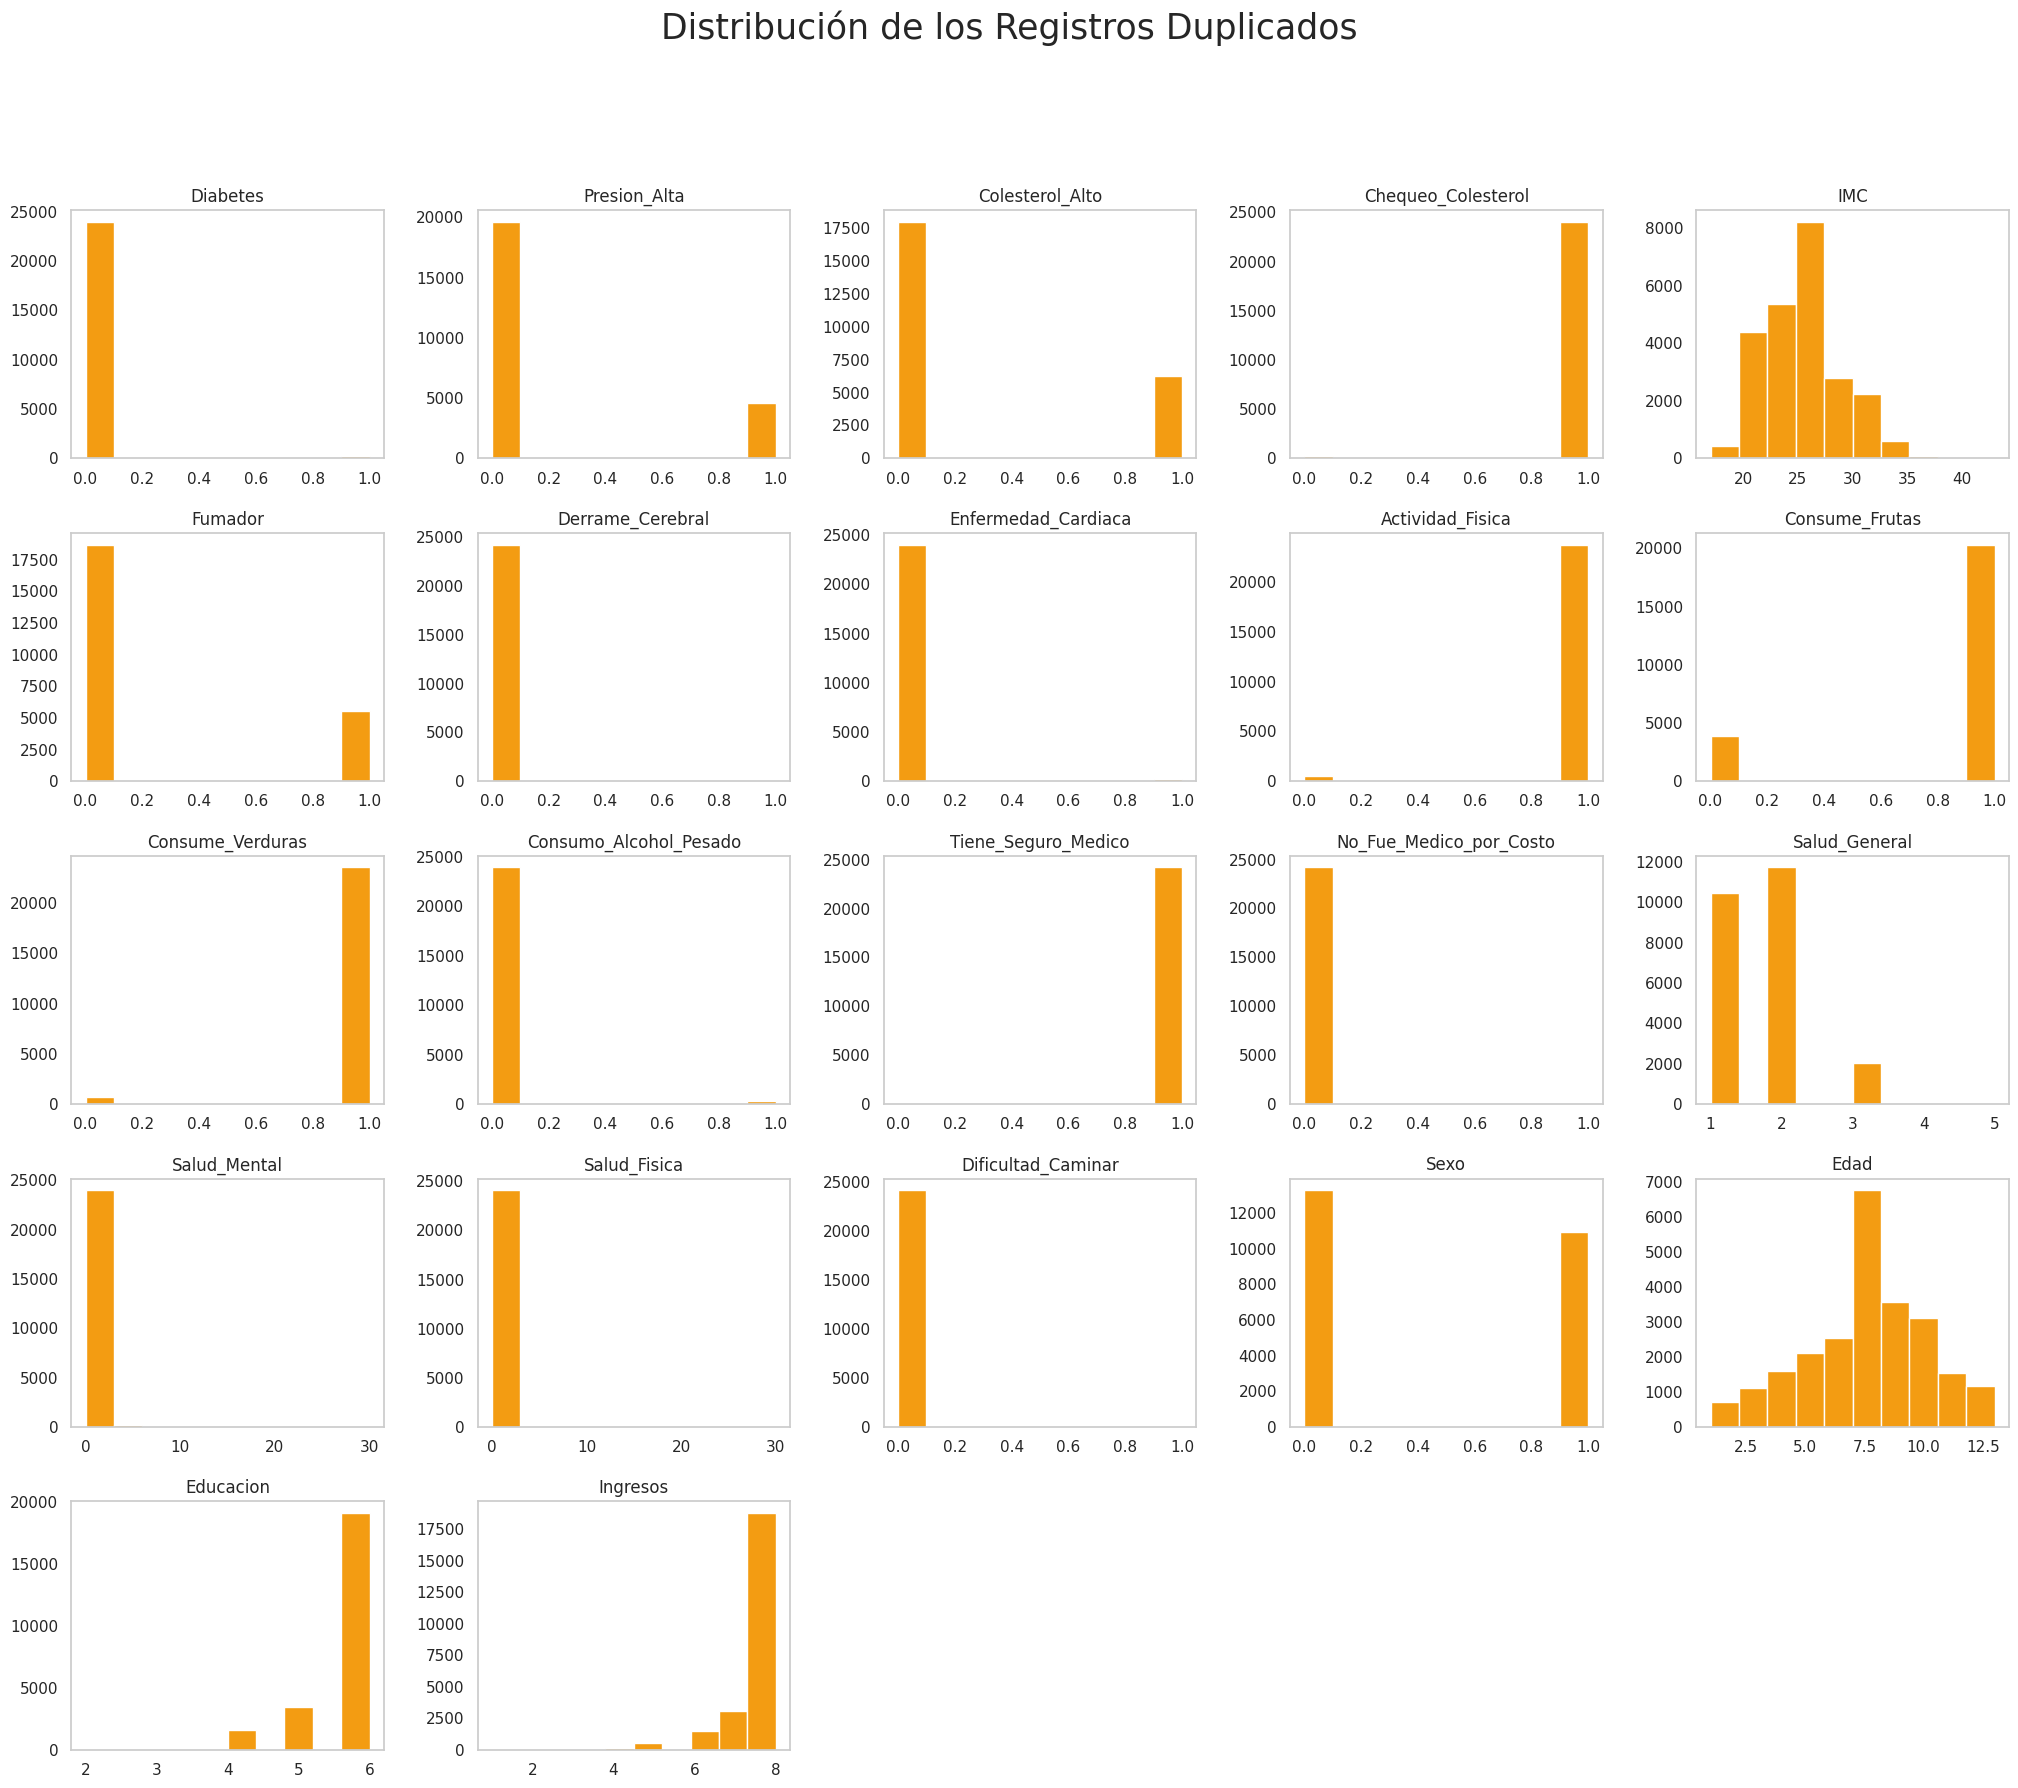

In [ ]:
# 1. Identificamos solo las filas que son duplicadas exactas
filas_duplicadas = data[data.duplicated()]

# 2. Graficamos sus histogramas para analizar su comportamiento
filas_duplicadas.hist(figsize=(25,20), color='#F39C12', edgecolor='white', grid=False)

plt.suptitle('Distribución de los Registros Duplicados', fontsize=25)
plt.show()

1. ¿Cuántos datos duplicados tienen diabetes?
--------------
De todos los registros que están repetidos, 249 personas tienen diabetes.

In [ ]:
value_counts = filas_duplicadas[filas_duplicadas['Diabetes'] == 1.0]['Diabetes'].value_counts()
print(value_counts)

Diabetes
1    249
Name: count, dtype: int64


2. ¿Cuántos de los datos duplicados no se han checado el colesterol y no tienen diabetes?
---------------------------

In [ ]:
value_counts = filas_duplicadas[filas_duplicadas['Chequeo_Colesterol'] == 0.0]['Diabetes'].value_counts()
print(value_counts)

Diabetes
0    172
Name: count, dtype: int64




*  Los datos duplicados no son errores ,son perfiles reales. La mayoría son no-diabéticos con hábitos de salud muy similares.
* Podemos  mantener estos registros para no perder la representatividad de la población sana en el modelo.



# Plan de Limpieza de Datos:
1.) Los datos ya cuentan con codificación  para las variables binarias de sí/no.

2.) Podemos Convertir todos los valores de punto flotante (floats) a enteros (ints) para mejorar la velocidad de procesamiento.

3.)No tenemosvalores nulos en el conjunto de datos.

4.) La mayoría de las variables son categóricas tipo sí/no. Esto debe tenerse en cuenta al seleccionar los modelos , graficos etc.

5.) Vamos optado por no eliminar los duplicados, ya que estos podrían revelar patrones, No parece que el origen de la duplicación sea un error. Si se eliminaran, la precisión de los modelos podría disminuir.



In [ ]:
# 1. Convertir todo a entero (ocupa menos memoria y es más rápido)
data = data.astype(int)
# Confirmar cambio
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   Diabetes                 253680 non-null  int64
 1   Presion_Alta             253680 non-null  int64
 2   Colesterol_Alto          253680 non-null  int64
 3   Chequeo_Colesterol       253680 non-null  int64
 4   IMC                      253680 non-null  int64
 5   Fumador                  253680 non-null  int64
 6   Derrame_Cerebral         253680 non-null  int64
 7   Enfermedad_Cardiaca      253680 non-null  int64
 8   Actividad_Fisica         253680 non-null  int64
 9   Consume_Frutas           253680 non-null  int64
 10  Consume_Verduras         253680 non-null  int64
 11  Consumo_Alcohol_Pesado   253680 non-null  int64
 12  Tiene_Seguro_Medico      253680 non-null  int64
 13  No_Fue_Medico_por_Costo  253680 non-null  int64
 14  Salud_General            253680 non-

# ETAPA 2. Comprensión de los Datos
-------
conoce a tu enemigo

# **A. Diagramas- cantidad de personas con y sin diabetes**

/tmp/ipykernel_2239/3937497200.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Diabetes', data=data, palette='magma')


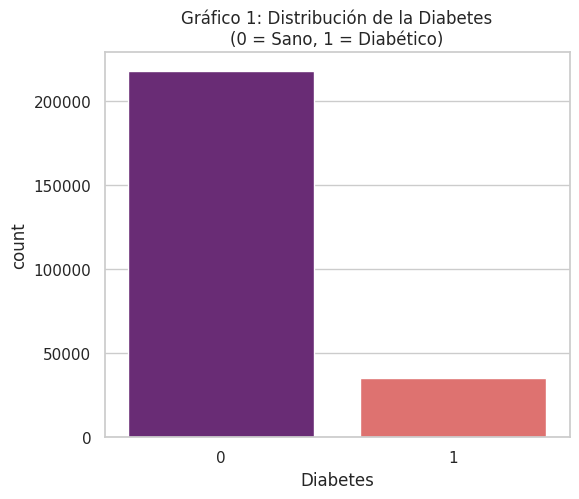

In [ ]:
# Configurar el estilo visual
sns.set_theme(style="whitegrid")

# 1. ¿Cuántos diabéticos vs sanos hay realmente?
plt.figure(figsize=(6,5))
sns.countplot(x='Diabetes', data=data, palette='magma')
plt.title('Gráfico 1: Distribución de la Diabetes\n(0 = Sano, 1 = Diabético)')
plt.show()

Estado_Diabetes
Sano         218334
Diabético     35346
Name: count, dtype: int64


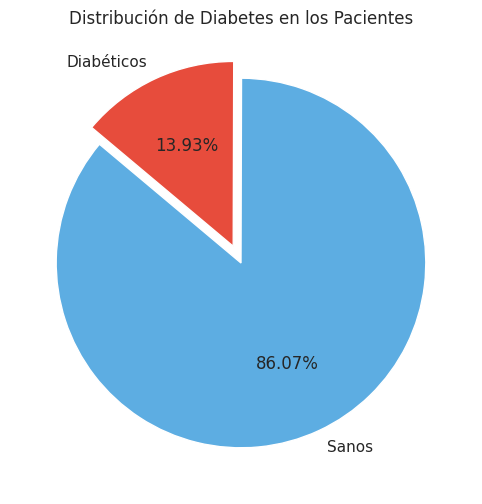

In [ ]:
# 1. Creamos una columna con texto para que las gráficas sean legibles
df['Estado_Diabetes'] = df['Diabetes'].replace({0: "Sano", 1: "Diabético"})

# 2. Obtenemos los conteos exactos
conteo_diabetes = df['Estado_Diabetes'].value_counts()
print(conteo_diabetes)

# 3. Gráfico de Pastel
etiquetas = ["Sanos", "Diabéticos"]
plt.figure(figsize=(8, 6))
plt.pie(conteo_diabetes,
        labels=etiquetas,
        autopct='%.2f%%',
        colors=["#5DADE2", "#E74C3C"], # Azul y Rojo
        startangle=140,
        explode=(0, 0.1)) # Resaltamos a los diabéticos

plt.title('Distribución de Diabetes en los Pacientes')
plt.show()

Estado_Diabetes
* Sano         218334
* Diabético     35346
* Name: count, dtype: int64

# **B. Mapa de calor**
---
El mapa de calor nos permite identificar qué variables tienen una relación más fuerte con la variable objetivo


*   Color Rojo Intenso: Relación fuerte positiva. Si esta variable sube, la probabilidad de diabetes sube.
* Color Azul: Relación negativa. Si esta variable sube, la diabetes baja (ej. Ingresos o Educación).

Los cuadros más rojos te dicen inmediatamente quiénes son los "culpables" más probables de la diabetes (como Salud_General, Presion_Alta e IMC). Los azules (negativos) te dicen qué factores protegen o disminuyen el riesgo (como Ingresos).

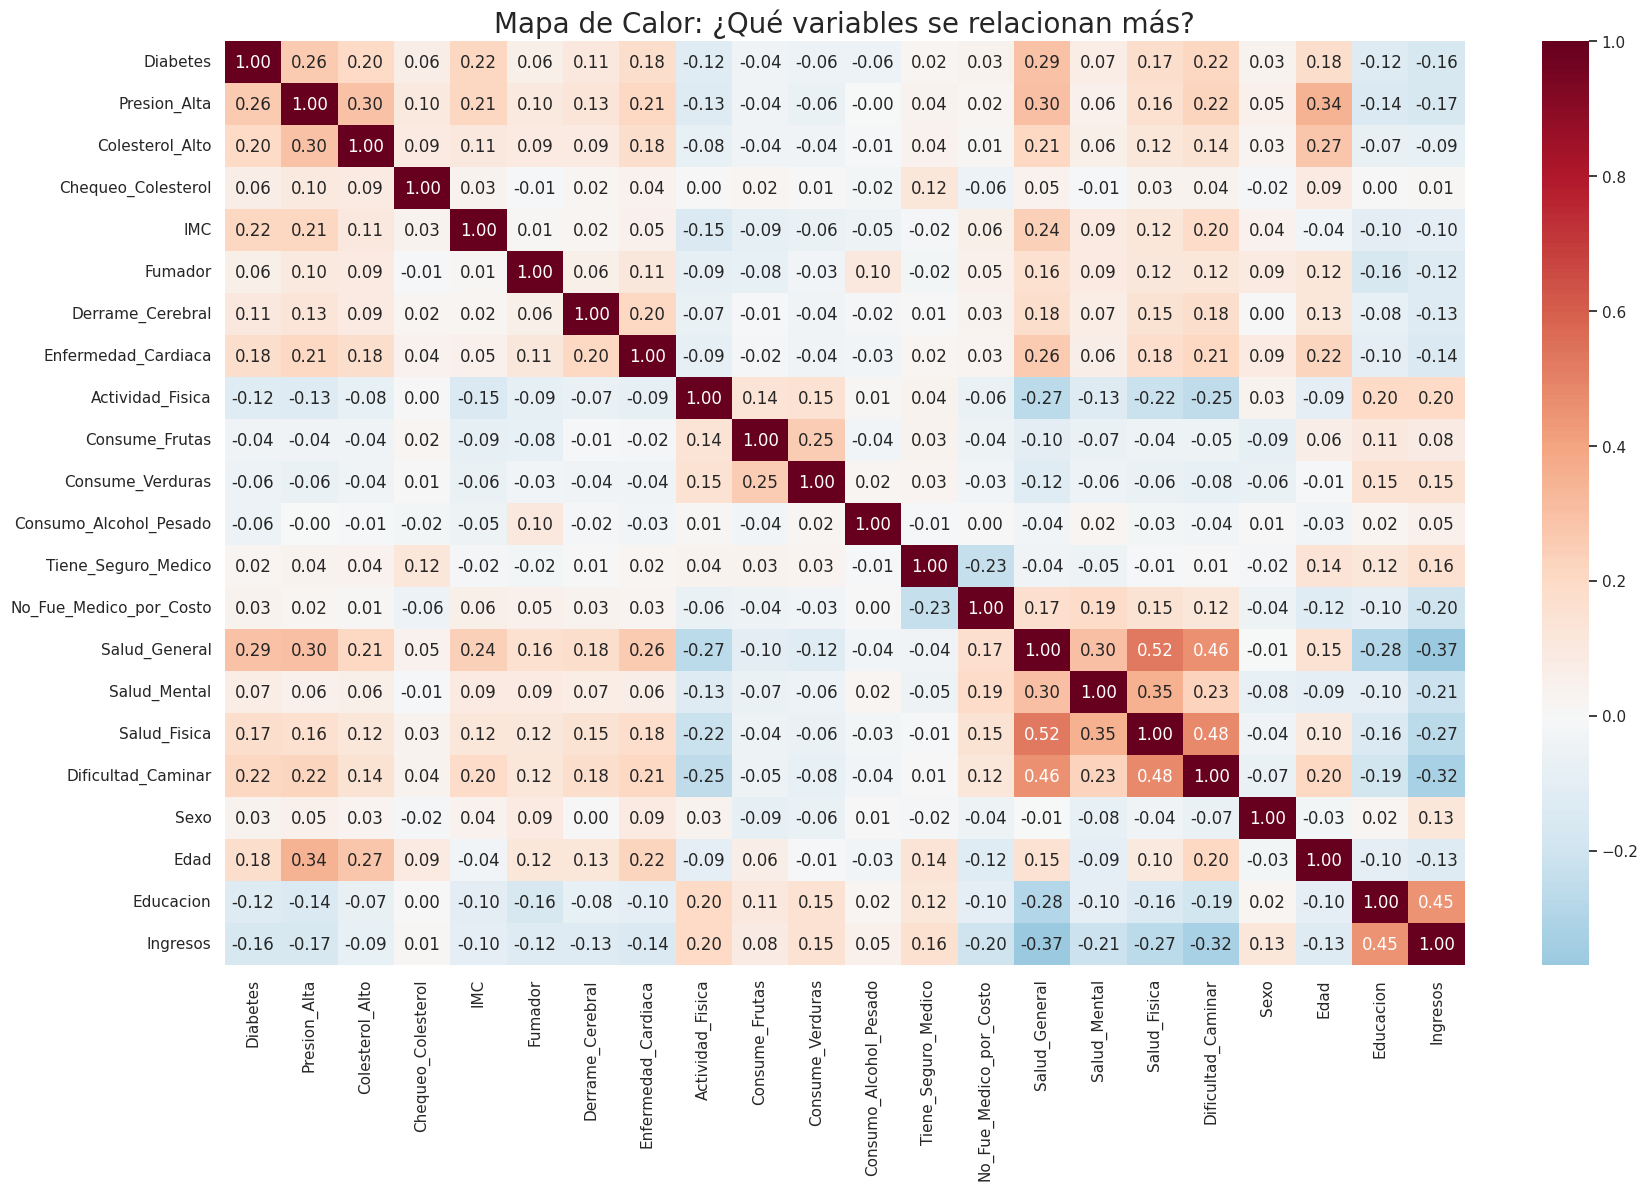

In [ ]:
# Calculamos la correlación
plt.figure(figsize=(20, 12))

sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='RdBu_r', center=0)

plt.title('Mapa de Calor: ¿Qué variables se relacionan más?', fontsize=20)
plt.show()

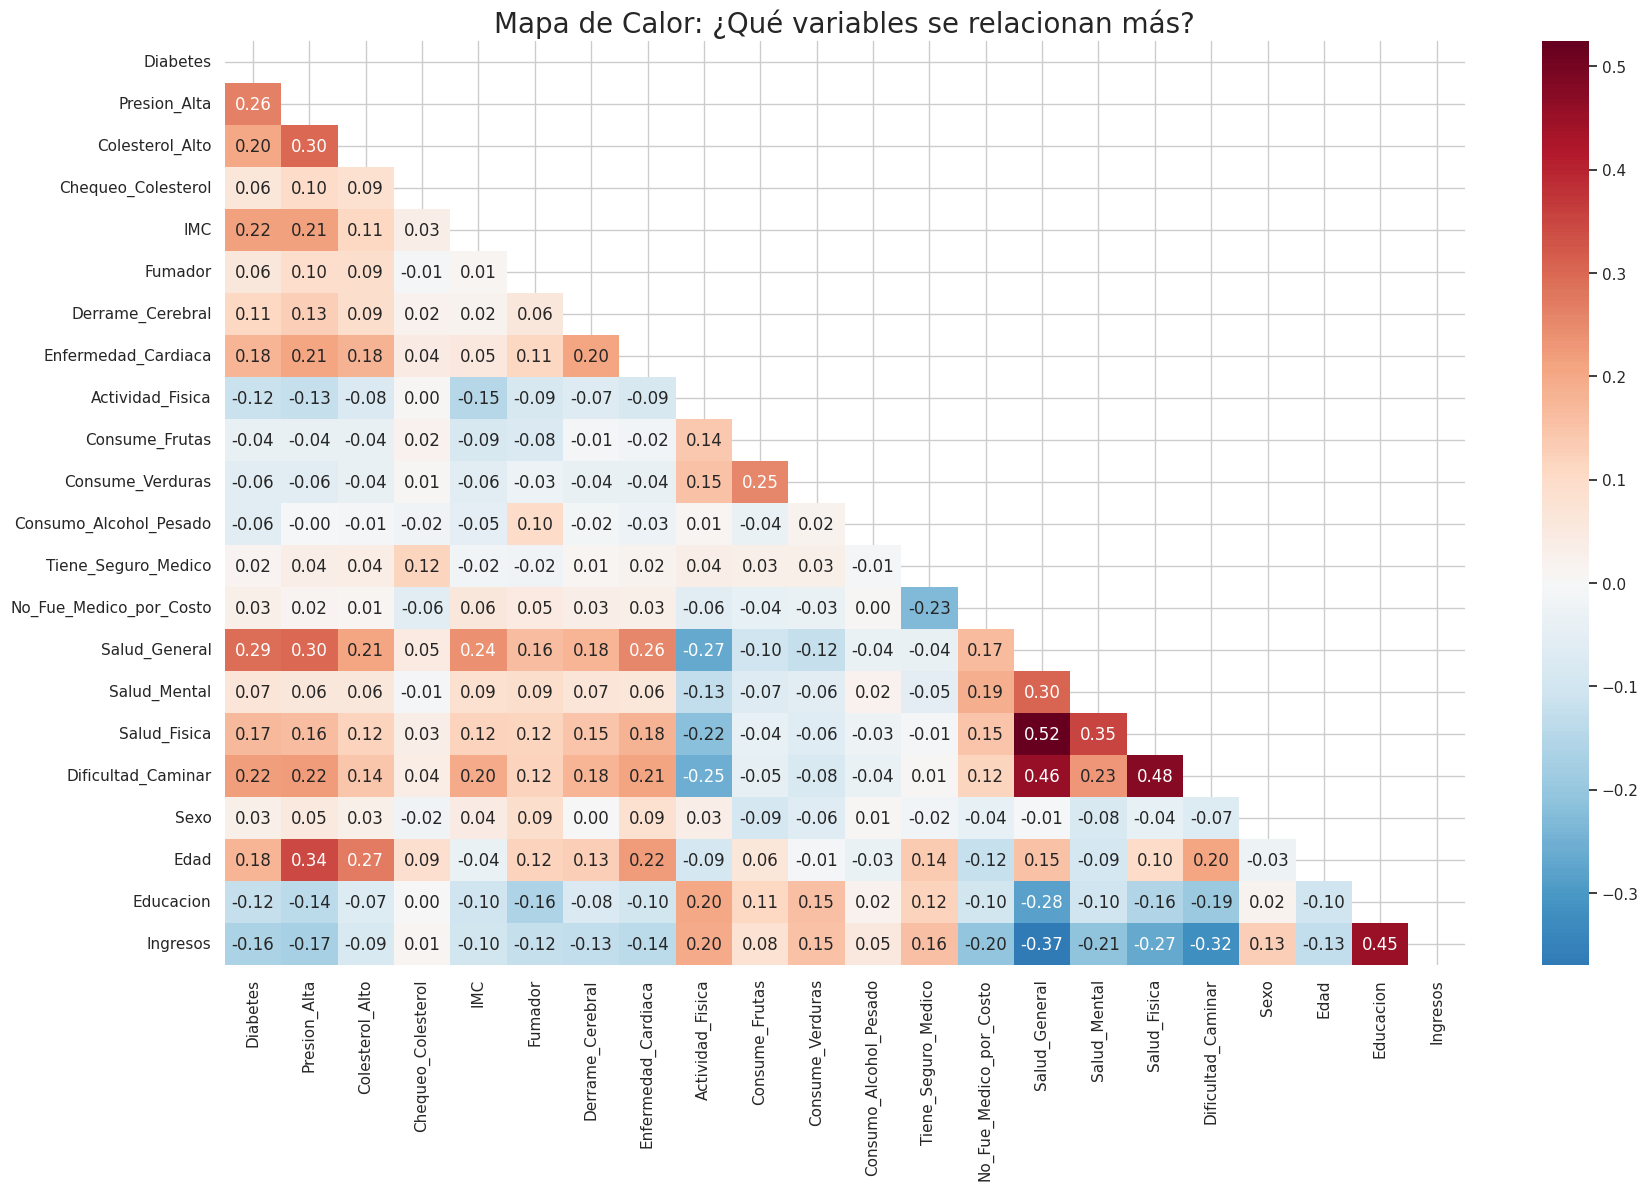

In [ ]:
# Calculamos la correlación
plt.figure(figsize=(20, 12))

sns.heatmap(df.corr(), mask=mask, annot=True, fmt=".2f", cmap='RdBu_r', center=0)

plt.title('Mapa de Calor: ¿Qué variables se relacionan más?', fontsize=20)
plt.show()


 Los Predictores más Fuertes:

*  Observamos que la Salud_General (0.29), la Presion_Alta (0.26) y el IMC (0.22) son las variables con mayor correlación positiva. Esto indica que a medida que empeora la percepción de salud, sube la presión o aumenta el índice de masa corporal, el riesgo de diabetes crece significativamente.

* Relaciones Secundarias Clave: Existe una fuerte conexión entre la Salud_General y la Salud_Fisica (0.52) y la Dificultad_Caminar (0.46). Esto sugiere que la diabetes no viene sola, sino que forma parte de un cuadro de deterioro físico generalizado.

* Factores Protectores: Variables como Ingresos (-0.16), Educacion (-0.12) y Actividad_Fisica (-0.12) ,presentan correlaciones negativas.
Estos datos tanbien nos pueden indicar que un mayor nivel socioeconómico y hábitos activos pueden actúan como barreras contra la enfermedad.


# **C.  Histogramas (Distribución)**
--------

*   Elemento de la lista
*   Elemento de la lista



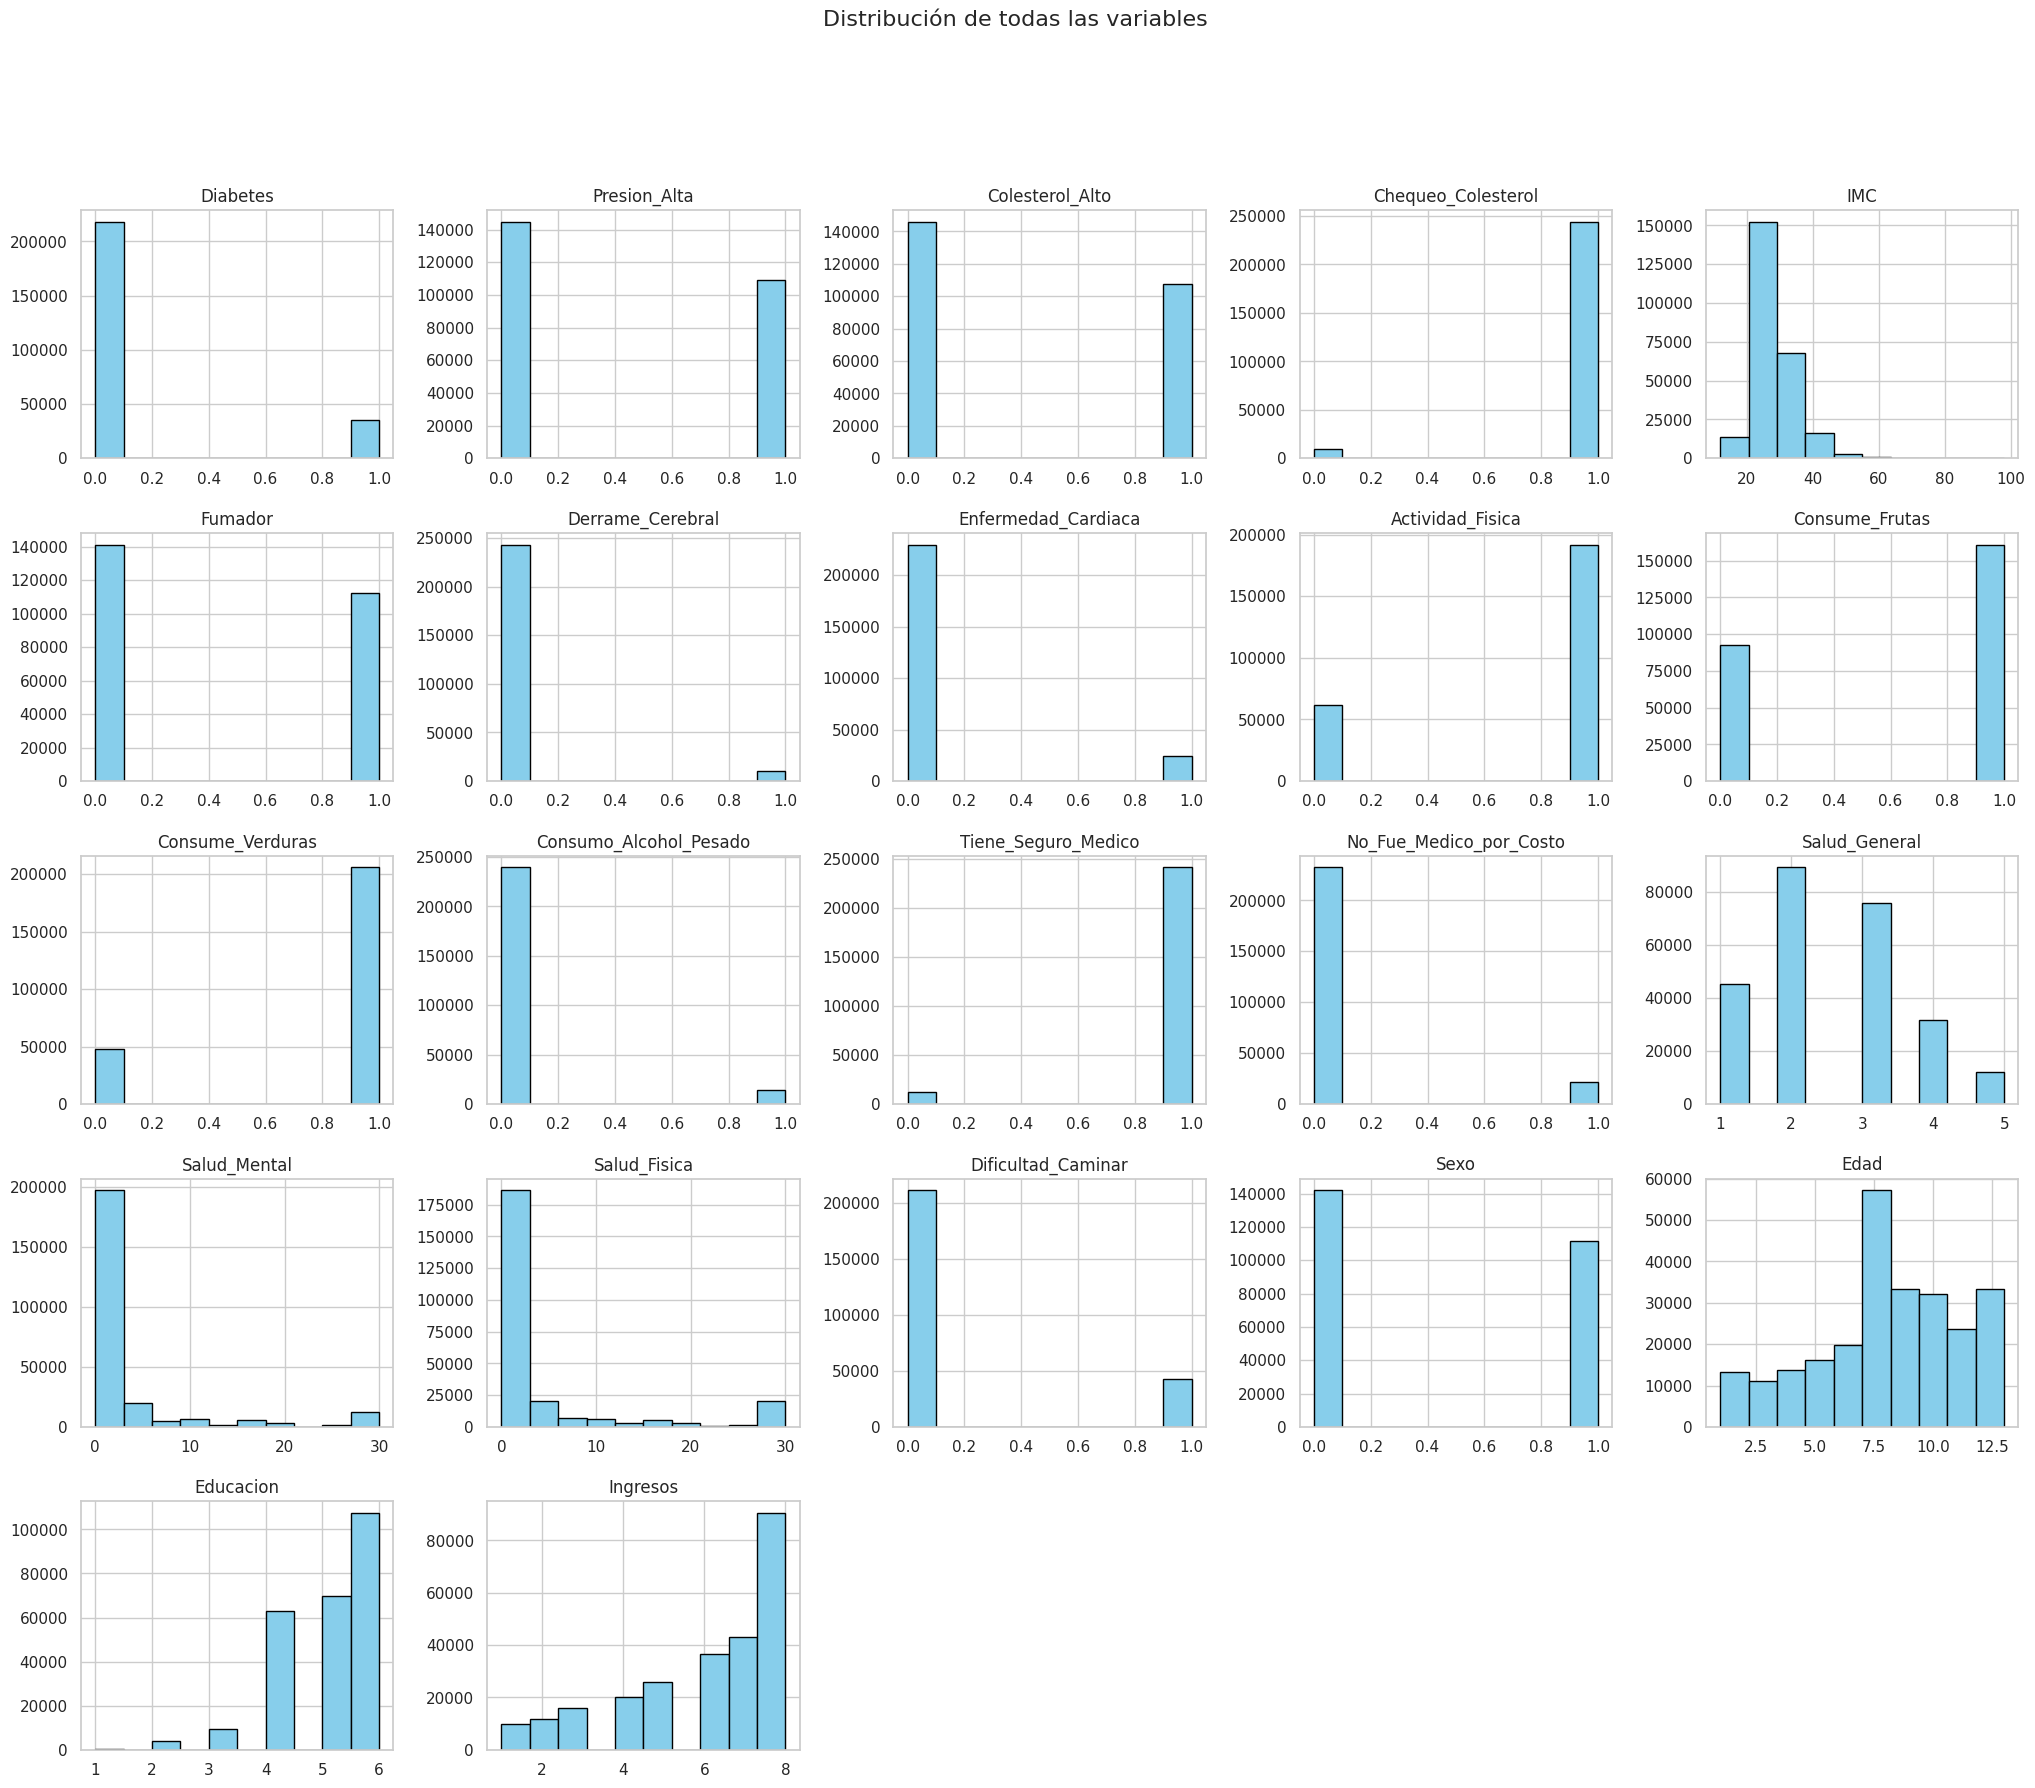

In [ ]:
# Genera histogramas para todas las variables
data.hist(figsize=(25,20), color='skyblue', edgecolor='black')
plt.suptitle("Distribución de todas las variables ", fontsize=16)
plt.show()

** Variables mas influyentes**

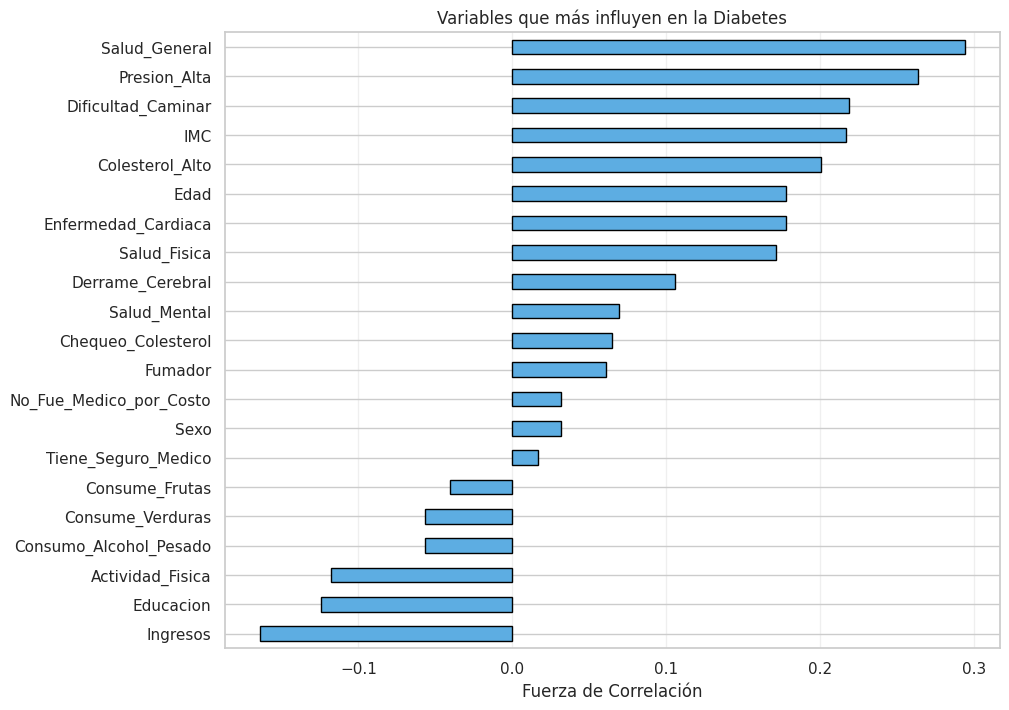

In [ ]:
# 1. Calcular y ordenar correlaciones
correlaciones = df.drop(['Diabetes', 'Estado_Diabetes'], axis=1).corrwith(df.Diabetes).sort_values()

# 2. Graficar
plt.figure(figsize=(10, 8))
correlaciones.plot(kind='barh', color='#5DADE2', edgecolor='black')

plt.title('Variables que más influyen en la Diabetes')
plt.xlabel('Fuerza de Correlación')
plt.grid(axis='x', alpha=0.3)
plt.show()

# **1) Presion_Alta**

Conclusión: Tener presión alta es como "abrirle la puerta" a la diabetes.

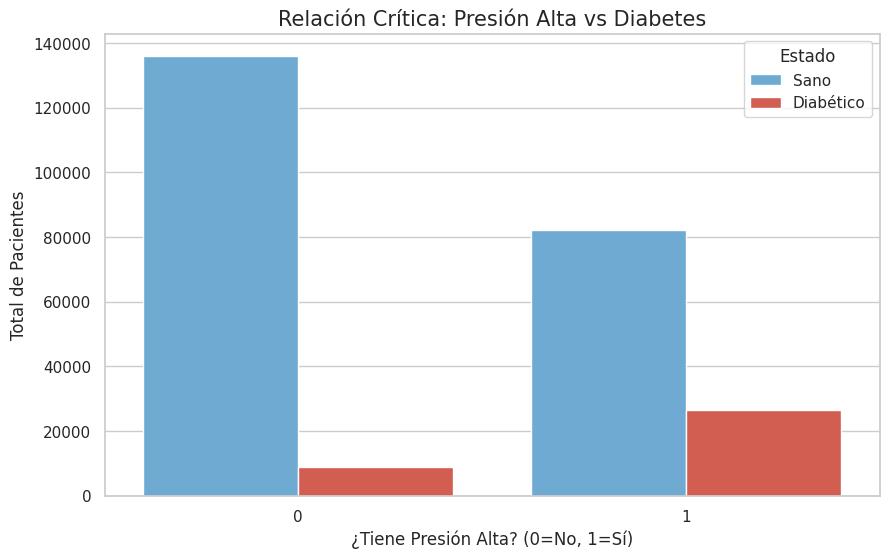

In [ ]:
# Gráfico de barras comparativo
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='Presion_Alta', hue='Diabetes', palette=['#5DADE2', '#E74C3C'])

plt.title('Relación Crítica: Presión Alta vs Diabetes', fontsize=15)
plt.xlabel('¿Tiene Presión Alta? (0=No, 1=Sí)')
plt.ylabel('Total de Pacientes')
plt.legend(title='Estado', labels=['Sano', 'Diabético'])
plt.show()

In [ ]:
# Obtener porcentajes para la relación entre Presión Alta y Diabetes
(df.groupby("Estado_Diabetes")["Presion_Alta"].value_counts(normalize=True) * 100).round(2)

Estado_Diabetes  Presion_Alta
Diabético        1               75.27
                 0               24.73
Sano             0               62.34
                 1               37.66
Name: proportion, dtype: float64

* El  75% de los diabéticos tienen presión alta. Es una cifra altísima que confirma que la presion alta es casi una "regla" en los pacientes con diabetes.

* En cambio, en las personas sanas, la mayoría tiene 62% de presión arterial normal.



# **2) Colesterol_Alto**

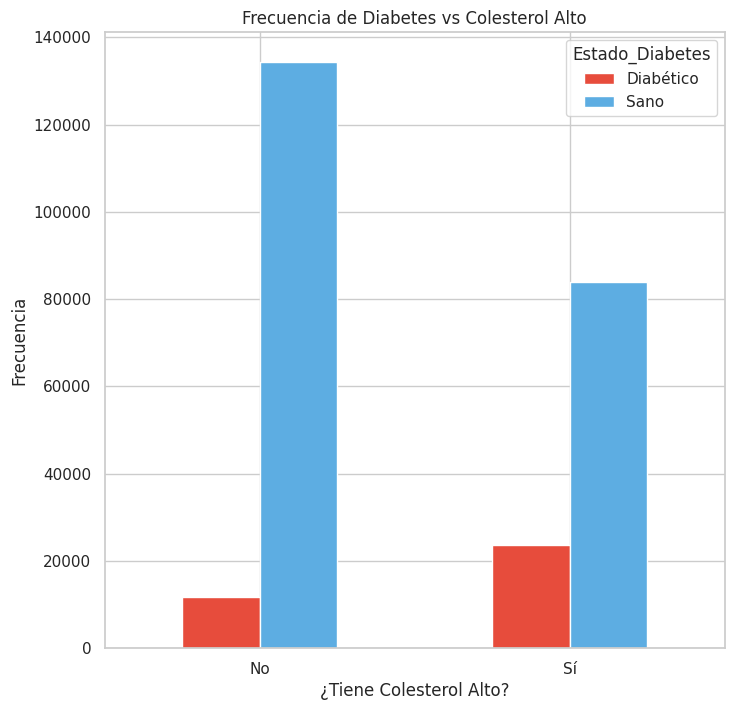

In [ ]:
# Crear una variable de texto para Colesterol_Alto
df['Colesterol_Alto_str'] = df['Colesterol_Alto'].replace({0:"No", 1:"Sí"})

# Gráfico de barras: Colesterol Alto vs Frecuencia de Diabetes
pd.crosstab(df.Colesterol_Alto_str, df.Estado_Diabetes).plot(kind='bar', figsize=(8,8), color=['#E74C3C','#5DADE2' ])
plt.title('Frecuencia de Diabetes vs Colesterol Alto')
plt.xlabel('¿Tiene Colesterol Alto?')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Obtener porcentajes de colesterol dentro de cada grupo de diabetes
(df.groupby('Estado_Diabetes')['Colesterol_Alto_str'].value_counts(normalize=True) * 100).round(2)

Estado_Diabetes  Colesterol_Alto_str
Diabético        Sí                     67.01
                 No                     32.99
Sano             No                     61.57
                 Sí                     38.43
Name: proportion, dtype: float64

Aunque es un factor fuerte, el porcentaje de diabéticos con colesterol alto suele ser menor que el de presión alta (aprox. 67% vs 75%).

**¿Qué pasa cuando un paciente tiene ambos problemas?**

In [ ]:
# Crear una variable de texto para Presion_Alta
df['Presion_Alta_str'] = df['Presion_Alta'].replace({0:"No", 1:"Sí"})

# Verificando la correlación de Presión Alta y Colesterol Alto juntos contra Diabetes
(df.groupby(["Presion_Alta_str", "Colesterol_Alto_str"])["Estado_Diabetes"].value_counts(normalize=True) * 100).round(2)

Presion_Alta_str  Colesterol_Alto_str  Estado_Diabetes
No                No                   Sano               95.81
                                       Diabético           4.19
                  Sí                   Sano               89.58
                                       Diabético          10.42
Sí                No                   Sano               83.27
                                       Diabético          16.73
                  Sí                   Sano               70.29
                                       Diabético          29.71
Name: proportion, dtype: float64

In [ ]:
# Agrupamos por los dos factores y vemos el porcentaje de diabéticos
riesgo_combinado = df.groupby(['Presion_Alta', 'Colesterol_Alto'])['Diabetes'].mean() * 100

print("Porcentaje de probabilidad de ser Diabético:")
print(f"Sin nada: {riesgo_combinado[0,0]:.2f}%")
print(f"Solo Colesterol Alto: {riesgo_combinado[0,1]:.2f}%")
print(f"Solo Presión Alta: {riesgo_combinado[1,0]:.2f}%")
print(f"CON AMBOS FACTORES: {riesgo_combinado[1,1]:.2f}%")

Porcentaje de probabilidad de ser Diabético:
Sin nada: 4.19%
Solo Colesterol Alto: 10.42%
Solo Presión Alta: 16.73%
CON AMBOS FACTORES: 29.71%



# **3. IMC (Índice de Masa Corporal)**



*  Conclusión visual: El diabético promedio tiene un IMC significativamente mayor que el sano.


/tmp/ipykernel_2239/570617555.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=data,  x='Diabetes', y='IMC', palette='Paired')
/tmp/ipykernel_2239/570617555.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Diabético', 'Diabético'])


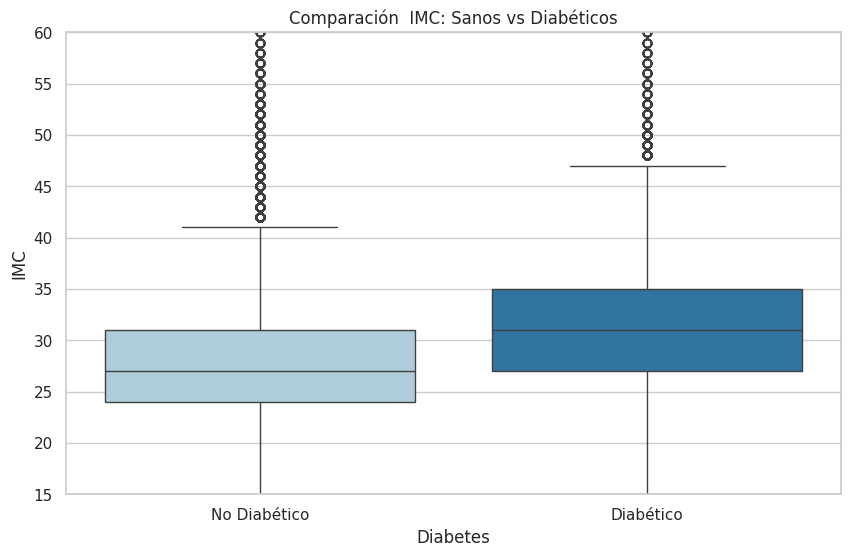

In [ ]:
# 1. Visualizar la distribución y posición de valores atípicos (outliers) en el IMC
plt.figure(figsize=(10, 6))
ax = sns.boxplot(data=data,  x='Diabetes', y='IMC', palette='Paired')

# Configuración de etiquetas y límites
ax.set(title='Comparación  IMC: Sanos vs Diabéticos')
ax.set_xticklabels(['No Diabético', 'Diabético'])
plt.ylim(15, 60) # Limitamos para ver mejor el cuerpo de los datos
plt.show()



*   1. La persona promedio con diabetes es más pesada que la persona promedio sana. Un IMC de 31 ya entra en la categoría de Obesidad, mientras que 27 es solo Sobrepeso.

* 2. Sanos: La mayoría está entre 24 y 31. Es un rango más bajo y saludable.

* 3. Diabéticos: La mayoría está entre 27 y 35. Fíjate que el inicio de la caja de los diabéticos (27) es donde ya está terminando la de los sanos.

* 4. A más IMC, más probabilidad de estar en el grupo diabético.

* 3. Los Puntos Negros (Valores Atípicos)
Esos puntos que suben hasta el 98 son personas con obesidad extrema.

* 4. Hay más puntos en el grupo de los Sanos simplemente porque hay muchas más personas sanas en tu estudio (218,334 vs 35,346).



In [ ]:
# Obtener estadísticas descriptivas para el IMC según el estado de diabetes
data.groupby('Diabetes')['IMC'].describe().round()

,count,mean,std,min,25%,50%,75%,max
Diabetes,,,,,,,,
0,218334.0,28.0,6.0,12.0,24.0,27.0,31.0,98.0
1,35346.0,32.0,7.0,13.0,27.0,31.0,35.0,98.0


# **4) Salud_General**

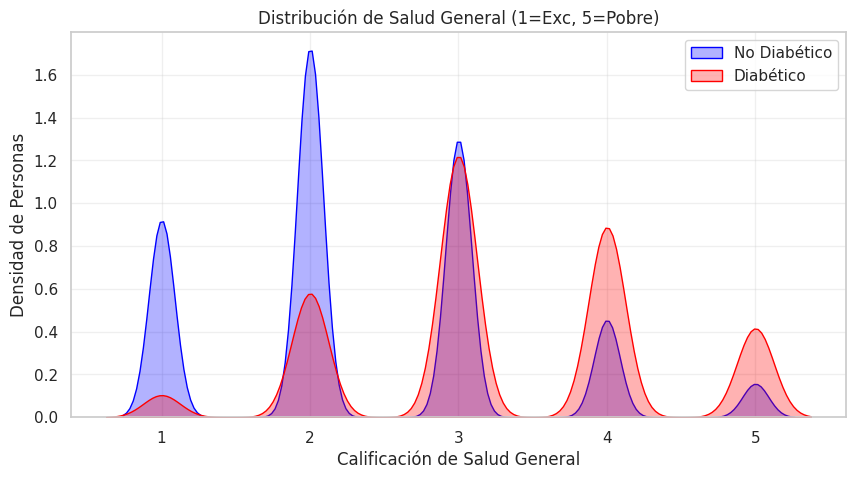

In [ ]:

df_sano = data[data['Diabetes'] == 0]
df_diabetico = data[data['Diabetes'] == 1]

plt.figure(figsize=(10, 5))
sns.kdeplot(df_sano['Salud_General'], color='blue', label='No Diabético', fill=True, alpha=0.3)
sns.kdeplot(df_diabetico['Salud_General'], color='red', label='Diabético', fill=True, alpha=0.3)

plt.grid(alpha=0.3)
plt.title('Distribución de Salud General (1=Exc, 5=Pobre)')
plt.xlabel('Calificación de Salud General')
plt.ylabel('Densidad de Personas')
plt.legend()
plt.show()

# **5. Salud_Física**

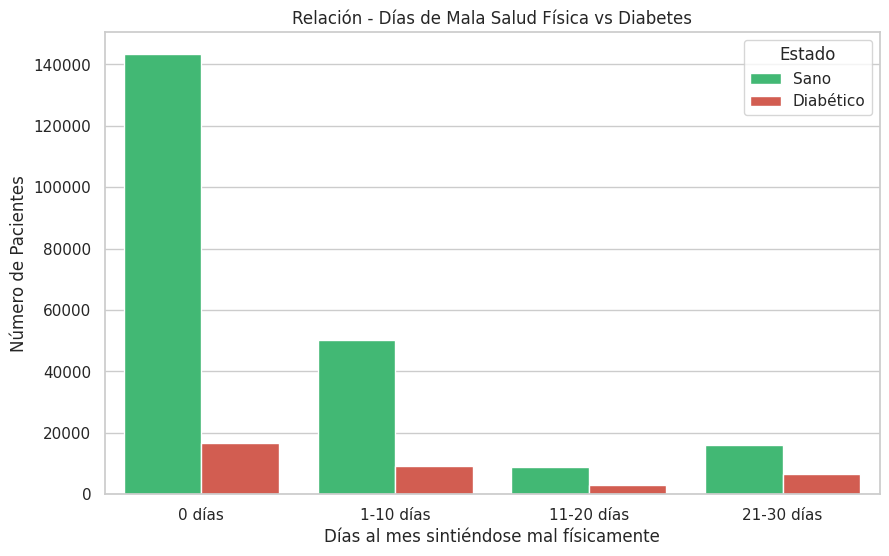

In [ ]:
# Creamos categorías para que sea fácil de entender
data['Rango_Salud_Fisica'] = pd.cut(data['Salud_Fisica'],
                                   bins=[-1, 0, 10, 20, 30],
                                   labels=['0 días', '1-10 días', '11-20 días', '21-30 días'])

# Creamos la columna 'Estado_Diabetes' en el DataFrame 'data'
data['Estado_Diabetes'] = data['Diabetes'].replace({0: "Sano", 1: "Diabético"})

# Graficamos
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='Rango_Salud_Fisica', hue='Estado_Diabetes', palette=['#2ECC71', '#E74C3C'])

plt.title('Relación - Días de Mala Salud Física vs Diabetes')
plt.xlabel('Días al mes sintiéndose mal físicamente')
plt.ylabel('Número de Pacientes')
plt.legend(title='Estado', labels=['Sano', 'Diabético'])
plt.show()



*    Ambas curvas tienen su punto más alto en el 0. Esto significa que la mayoría de las personas, incluso las diabéticas, reportan no haber tenido días malos en el mes.

*  las curvas coinciden de cerca esto nos dice que la diabetes no siempre se manifiesta como un dolor físico constante para todos los pacientes.

* tambien hay  un grupo con complicaciones crónicas que se sienten mal todos los días del mes.



# **6) Dificultad para Caminar**

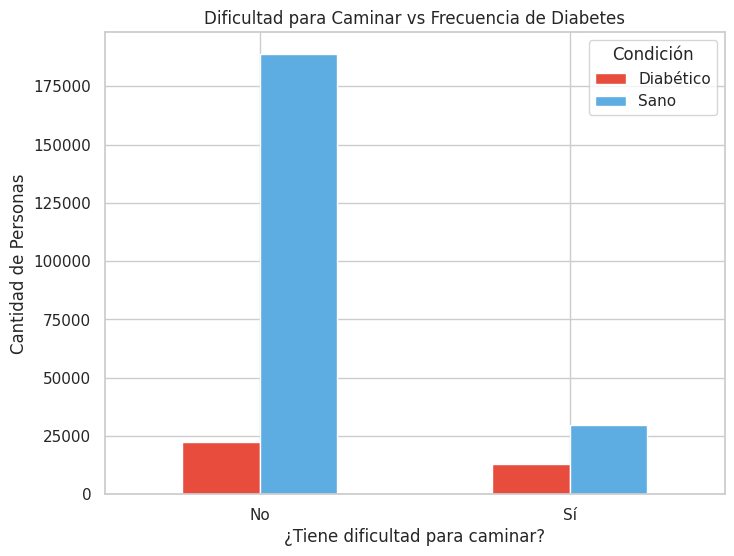

In [ ]:
# Crear variable de texto si no la tienes
df["Dificultad_Caminar_str"] = df["Dificultad_Caminar"].replace({0:"No", 1:"Sí"})

# Graficar
pd.crosstab(df.Dificultad_Caminar_str, df.Estado_Diabetes).plot(kind='bar', figsize=(8,6), color=['#E74C3C', '#5DADE2'])

plt.title('Dificultad para Caminar vs Frecuencia de Diabetes')
plt.xlabel('¿Tiene dificultad para caminar?')
plt.ylabel('Cantidad de Personas')
plt.xticks(rotation=0)
plt.legend(title='Condición')
plt.show()

In [ ]:
(df.groupby("Diabetes")["Dificultad_Caminar_str"].value_counts()/df.groupby("Diabetes")["Dificultad_Caminar_str"].count()).round(4)*100

Diabetes  Dificultad_Caminar_str
0         No                        86.46
          Sí                        13.54
1         No                        62.88
          Sí                        37.12
dtype: float64

* Diabéticos: El 37.12% tiene dificultades para caminar. Es decir, casi 4 de cada 10 personas con diabetes sufren de movilidad reducida.

* No Diabéticos: Solo el 13.54% reporta este problema.

# - Seleccionamos las variables

In [ ]:
# Definimos que queremos las 10 mejores variables
umbral = 7

In [ ]:
# --- MÉTODO 1: INFORMACIÓN MUTUA (MIC) ---
# Mide cuánto aporta cada variable a reducir la incertidumbre sobre la diabetes.
puntajes_mic = mutual_info_classif(caracteristicas_res, objetivo_res, random_state=0)
mejores_mic = [nombre for score, nombre in sorted(zip(puntajes_mic, caracteristicas_res.columns), reverse=True)[:umbral]]
print(f"Top 10 MIC: {mejores_mic}")

Top 10 MIC: ['Salud_Fisica', 'Salud_General', 'Salud_Mental', 'Dificultad_Caminar', 'Ingresos', 'IMC', 'Actividad_Fisica']


In [ ]:
# --- MÉTODO 2: PRUEBA DE CHI-CUADRADO (Chi-Squared) ---
# Evalúa la dependencia estadística entre las variables y la diabetes.
skb = SelectKBest(score_func=chi2, k=umbral)
skb.fit(caracteristicas_res, objetivo_res)
mejores_chi2 = list(caracteristicas_res.columns[skb.get_support()])
print(f"Top 10 Chi2: {mejores_chi2}")

Top 10 Chi2: ['IMC', 'Enfermedad_Cardiaca', 'Salud_General', 'Salud_Mental', 'Salud_Fisica', 'Dificultad_Caminar', 'Ingresos']


In [ ]:
# --- MÉTODO 3: CORRELACIÓN DE PEARSON ---
# Mide la relación lineal directa.
lista_pearson = []
for col in caracteristicas_res.columns:
    coeficiente, _ = pearsonr(caracteristicas_res[col], objetivo_res)
    lista_pearson.append(abs(coeficiente))

serie_p = pd.Series(lista_pearson, index=caracteristicas_res.columns)
mejores_pearson = list(serie_p.sort_values(ascending=False).index[:umbral])
print(f"Top 10 Pearson: {mejores_pearson}")

Top 10 Pearson: ['Salud_General', 'Salud_Fisica', 'Ingresos', 'Dificultad_Caminar', 'Salud_Mental', 'IMC', 'Actividad_Fisica']


In [ ]:
# En lugar de intersección, suma cuántas veces aparece cada variable en los tops
todas_las_seleccionadas = mejores_mic + mejores_chi2 + mejores_pearson
votos = pd.Series(todas_las_seleccionadas).value_counts()

# Quedarse con las que tengan al menos 2 votos de 3
variables_finales = votos[votos >= 2].index.tolist()
print(f"Variables finales (Votación): {variables_finales}")

Variables finales (Votación): ['Salud_Fisica', 'Salud_General', 'Salud_Mental', 'Dificultad_Caminar', 'Ingresos', 'IMC', 'Actividad_Fisica']


## Resumen de Variables Analizadas
Hemos analizado 6 variables clave (predictores) para entender su relación con la Diabetes (nuestra variable objetivo). A continuación, se detalla cada una:

**Variable Objetivo**

*   **Diabetes**: Indica si el paciente tiene diabetes (1) o no (0).

**Variables Predictoras (Factores de Riesgo)**

| Variable           | Nombre en Dataset | Tipo      | Lo que mide                                                  |
| :----------------- | :---------------- | :-------- | :----------------------------------------------------------- |
| **A.) Presión Alta** | `Presion_Alta`      | Binaria   | Si el paciente tiene presión arterial alta (0 = No, 1 = Sí). |
| **B.) Colesterol**   | `Colesterol_Alto`   | Binaria   | Si el paciente tiene colesterol alto (0 = No, 1 = Sí).       |
| **C.) IMC (BMI)**    | `IMC`               | Numérica  | Índice de Masa Corporal (Relación peso/estatura).            |
| **D.) Salud General**| `Salud_General`     | Ordinal   | Autopercepción de salud (1 = Excelente a 5 = Pobre).         |
| **E.) Salud Física** | `Salud_Fisica`      | Numérica  | Días al mes con malestar físico (rango 0 a 30).              |
| **F.) Movilidad**    | `Dificultad_Caminar`| Binaria   | Dificultad seria para caminar o subir escaleras (0=No, 1=Sí).|